# Analyse des erreurs de géoréférencement — multi-outages

Charge les LAS `rmse_*.las` (champ `e3d`) produits par `rmse_streaming.py`  
pour **plusieurs outages simultanément**, avec bornes et exclusions indépendantes.

**Dépendances** : `laspy`, `numpy`, `pandas`, `matplotlib`

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import laspy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.35,
})

## 1. Configuration — un bloc par outage

Ajoute/supprime des entrées dans `OUTAGES`.  
Chaque outage est un `dict` avec :
- `id` : label affiché
- `output_dir` : dossier racine contenant les sous-dossiers par méthode
- `methods` : liste de noms de méthodes (ou `None` pour détecter auto)
- `t_min` / `t_max` : bornes du plot en GPS time (SOW)
- `exclusion_zones` : liste de tuples `(t_a, t_b)` à griser
- `imu` : label de l'IMU utilisé (affiché dans les titres)

In [23]:
BASE = Path("/media/b085164/LaCie/2026spring_RD/CALIB_26_02_25/georef_errors")
BASE_EL = Path("/media/b085164/Elements/CALIB_26_02_25")

OUTAGES = [
    {
        "id":    "Outage 1",
        "imu":   "APX",
        "output_dir": BASE / "outage_1" / "APX",
        "methods": ["OUTAGE", "F2B", "COMBINED"],
        "t_min": 305200.0,
        "t_max": 305620.0,
        "exclusion_zones": [],   # à remplir si besoin
    },
    {
        "id":    "Outage 2",
        "imu":   "APX",
        "output_dir": BASE / "outage_2" / "APX",
        "methods": ["OUTAGE", "F2B", "COMBINED"],
        "t_min": 305645.0,
        "t_max": 306120.0,
        "exclusion_zones": [],
    },
    {
        "id":    "Outage 3",
        "imu":   "APX",
        "output_dir": BASE / "outage_3" / "APX",
        "methods": ["OUTAGE", "F2B", "COMBINED"],
        "t_min": 306290.0,
        "t_max": 306645.0,
        "exclusion_zones": [(306405.0, 306560.0)],
    },
]

# ── Paramètres globaux ────────────────────────────────────────────────────────
THRESHOLD_LINES = [0.10, 0.50, 1.00]   # traits horizontaux (m)
SMOOTH_WINDOW   = 50                    # lissage (pts), 1 = désactivé

METHOD_COLORS = {
    "outage_traj": "#e74c3c",   # rouge  — INS-only
    "F2B":         "#f39c12",   # orange
    "S2S":         "#3498db",   # bleu
    "COMBINED":    "#27ae60",   # vert
}
_fallback_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def method_color(name, idx=0):
    return METHOD_COLORS.get(name, _fallback_colors[idx % len(_fallback_colors)])

## 2. Fonctions utilitaires

In [24]:
def load_las_e3d(las_path: Path):
    """Retourne (t, e3d) triés depuis un LAS rmse_streaming."""
    with laspy.open(las_path) as f:
        pts = f.read()
    t   = np.asarray(pts.gps_time, dtype=np.float64)
    e3d = np.asarray(pts['e3d'],   dtype=np.float32)
    order = np.argsort(t)
    return t[order], e3d[order]


def discover_and_load(output_dir: Path, methods=None):
    """
    Charge tous les LAS rmse_*.las dans output_dir/<method>/.
    Retourne :
      data        : {method: (t, e3d)}
      file_index  : {method: [Path, ...]}
    """
    if methods is None:
        methods = sorted(d.name for d in output_dir.iterdir() if d.is_dir())

    data, file_index = {}, {}
    for m in methods:
        mdir = output_dir / m
        if not mdir.exists():
            print(f"  ⚠ {m}: dossier introuvable ({mdir})")
            continue
        files = sorted(mdir.glob("rmse_*.las"))
        if not files:
            print(f"  ⚠ {m}: aucun rmse_*.las")
            continue
        file_index[m] = files
        ts, es = [], []
        for f in files:
            try:
                t, e = load_las_e3d(f)
                ts.append(t); es.append(e)
            except Exception as ex:
                print(f"  ✗ {f.name}: {ex}")
        if ts:
            t_cat = np.concatenate(ts)
            e_cat = np.concatenate(es)
            order = np.argsort(t_cat)
            data[m] = (t_cat[order], e_cat[order])
    return data, file_index


def compute_metrics(t, e, t_min=None, t_max=None, excl_zones=None):
    mask = np.ones(len(t), dtype=bool)
    if t_min is not None: mask &= (t >= t_min)
    if t_max is not None: mask &= (t <= t_max)
    for za, zb in (excl_zones or []):
        mask &= ~((t >= za) & (t <= zb))
    e = e[mask]
    nan = {k: np.nan for k in ['N','RMSE','mean','Q50','Q75','Q90','Q95','Q99',
                                'max','%>0.10m','%>0.50m','%>1.00m']}
    if len(e) == 0: return nan
    return {
        'N':        len(e),
        'RMSE':     float(np.sqrt(np.mean(e**2))),
        'mean':     float(np.mean(e)),
        'Q50':      float(np.percentile(e, 50)),
        'Q75':      float(np.percentile(e, 75)),
        'Q90':      float(np.percentile(e, 90)),
        'Q95':      float(np.percentile(e, 95)),
        'Q99':      float(np.percentile(e, 99)),
        'max':      float(np.max(e)),
        '%>0.10m':  float(np.mean(e > 0.10) * 100),
        '%>0.50m':  float(np.mean(e > 0.50) * 100),
        '%>1.00m':  float(np.mean(e > 1.00) * 100),
    }


def smooth(arr, w):
    if w <= 1 or len(arr) < w: return arr
    return np.convolve(arr, np.ones(w)/w, mode='same')

## 3. Chargement de tous les outages

In [25]:
# Résultat : liste de dicts enrichis avec data + file_index
outages = []
for cfg in OUTAGES:
    print(f"\n{'─'*60}")
    print(f"  {cfg['id']} — {cfg['imu']}  [{cfg['t_min']:.0f} – {cfg['t_max']:.0f}]")
    d, fi = discover_and_load(cfg['output_dir'], cfg.get('methods'))
    for m, (t, e) in d.items():
        print(f"  ✓ {m:20s}  {len(t):>10,} pts  t=[{t.min():.1f}, {t.max():.1f}]")
    outages.append({**cfg, 'data': d, 'file_index': fi})


────────────────────────────────────────────────────────────
  Outage 1 — APX  [305200 – 305620]
  ⚠ OUTAGE: dossier introuvable (/media/b085164/LaCie/2026spring_RD/CALIB_26_02_25/georef_errors/outage_1/APX/OUTAGE)
  ✓ F2B                   24,761,062 pts  t=[305140.0, 305680.0]
  ✓ COMBINED              21,538,023 pts  t=[305170.0, 305650.0]

────────────────────────────────────────────────────────────
  Outage 2 — APX  [305645 – 306120]
  ⚠ OUTAGE: dossier introuvable (/media/b085164/LaCie/2026spring_RD/CALIB_26_02_25/georef_errors/outage_2/APX/OUTAGE)
  ✓ F2B                   29,189,252 pts  t=[305635.0, 306130.0]
  ✓ COMBINED              23,312,424 pts  t=[305635.0, 306130.0]

────────────────────────────────────────────────────────────
  Outage 3 — APX  [306290 – 306645]
  ⚠ OUTAGE: dossier introuvable (/media/b085164/LaCie/2026spring_RD/CALIB_26_02_25/georef_errors/outage_3/APX/OUTAGE)
  ✓ F2B                   28,290,762 pts  t=[306280.0, 306655.0]
  ✓ COMBINED              2

## 4. Tableau de métriques — tous outages

Index : `(outage_id, imu, method)` — colonnes principales : RMSE, Q50, Q95, Q99, max, %>0.50m, %>1.00m.

In [5]:
rows = []
for o in outages:
    for method, (t, e) in o['data'].items():
        m = compute_metrics(t, e, o['t_min'], o['t_max'], o['exclusion_zones'])
        rows.append({'outage': o['id'], 'imu': o['imu'], 'method': method, **m})

df_all = pd.DataFrame(rows).set_index(['outage', 'imu', 'method'])

fmt = {
    'N':        '{:,.0f}',
    'RMSE':     '{:.4f} m',
    'mean':     '{:.4f} m',
    'Q50':      '{:.4f} m',
    'Q75':      '{:.4f} m',
    'Q90':      '{:.4f} m',
    'Q95':      '{:.4f} m',
    'Q99':      '{:.4f} m',
    'max':      '{:.4f} m',
    '%>0.10m':  '{:.1f} %',
    '%>0.50m':  '{:.1f} %',
    '%>1.00m':  '{:.1f} %',
}

display(
    df_all.style
    .format(fmt, na_rep='—')
    .highlight_min(subset=['RMSE','Q95','Q99'], color='#d4edda', axis=0)
    .highlight_max(subset=['RMSE','Q95','Q99'], color='#f8d7da', axis=0)
    .set_caption("Métriques d'erreur 3D — tous outages (exclusions appliquées)")
    .set_table_styles([{'selector':'th','props':'background:#f0f0f0;font-weight:bold'}])
)

## 5. Plot erreur 3D vs temps GPS — un panneau par outage

Chaque panneau affiche toutes les méthodes de cet outage sur le même axe.

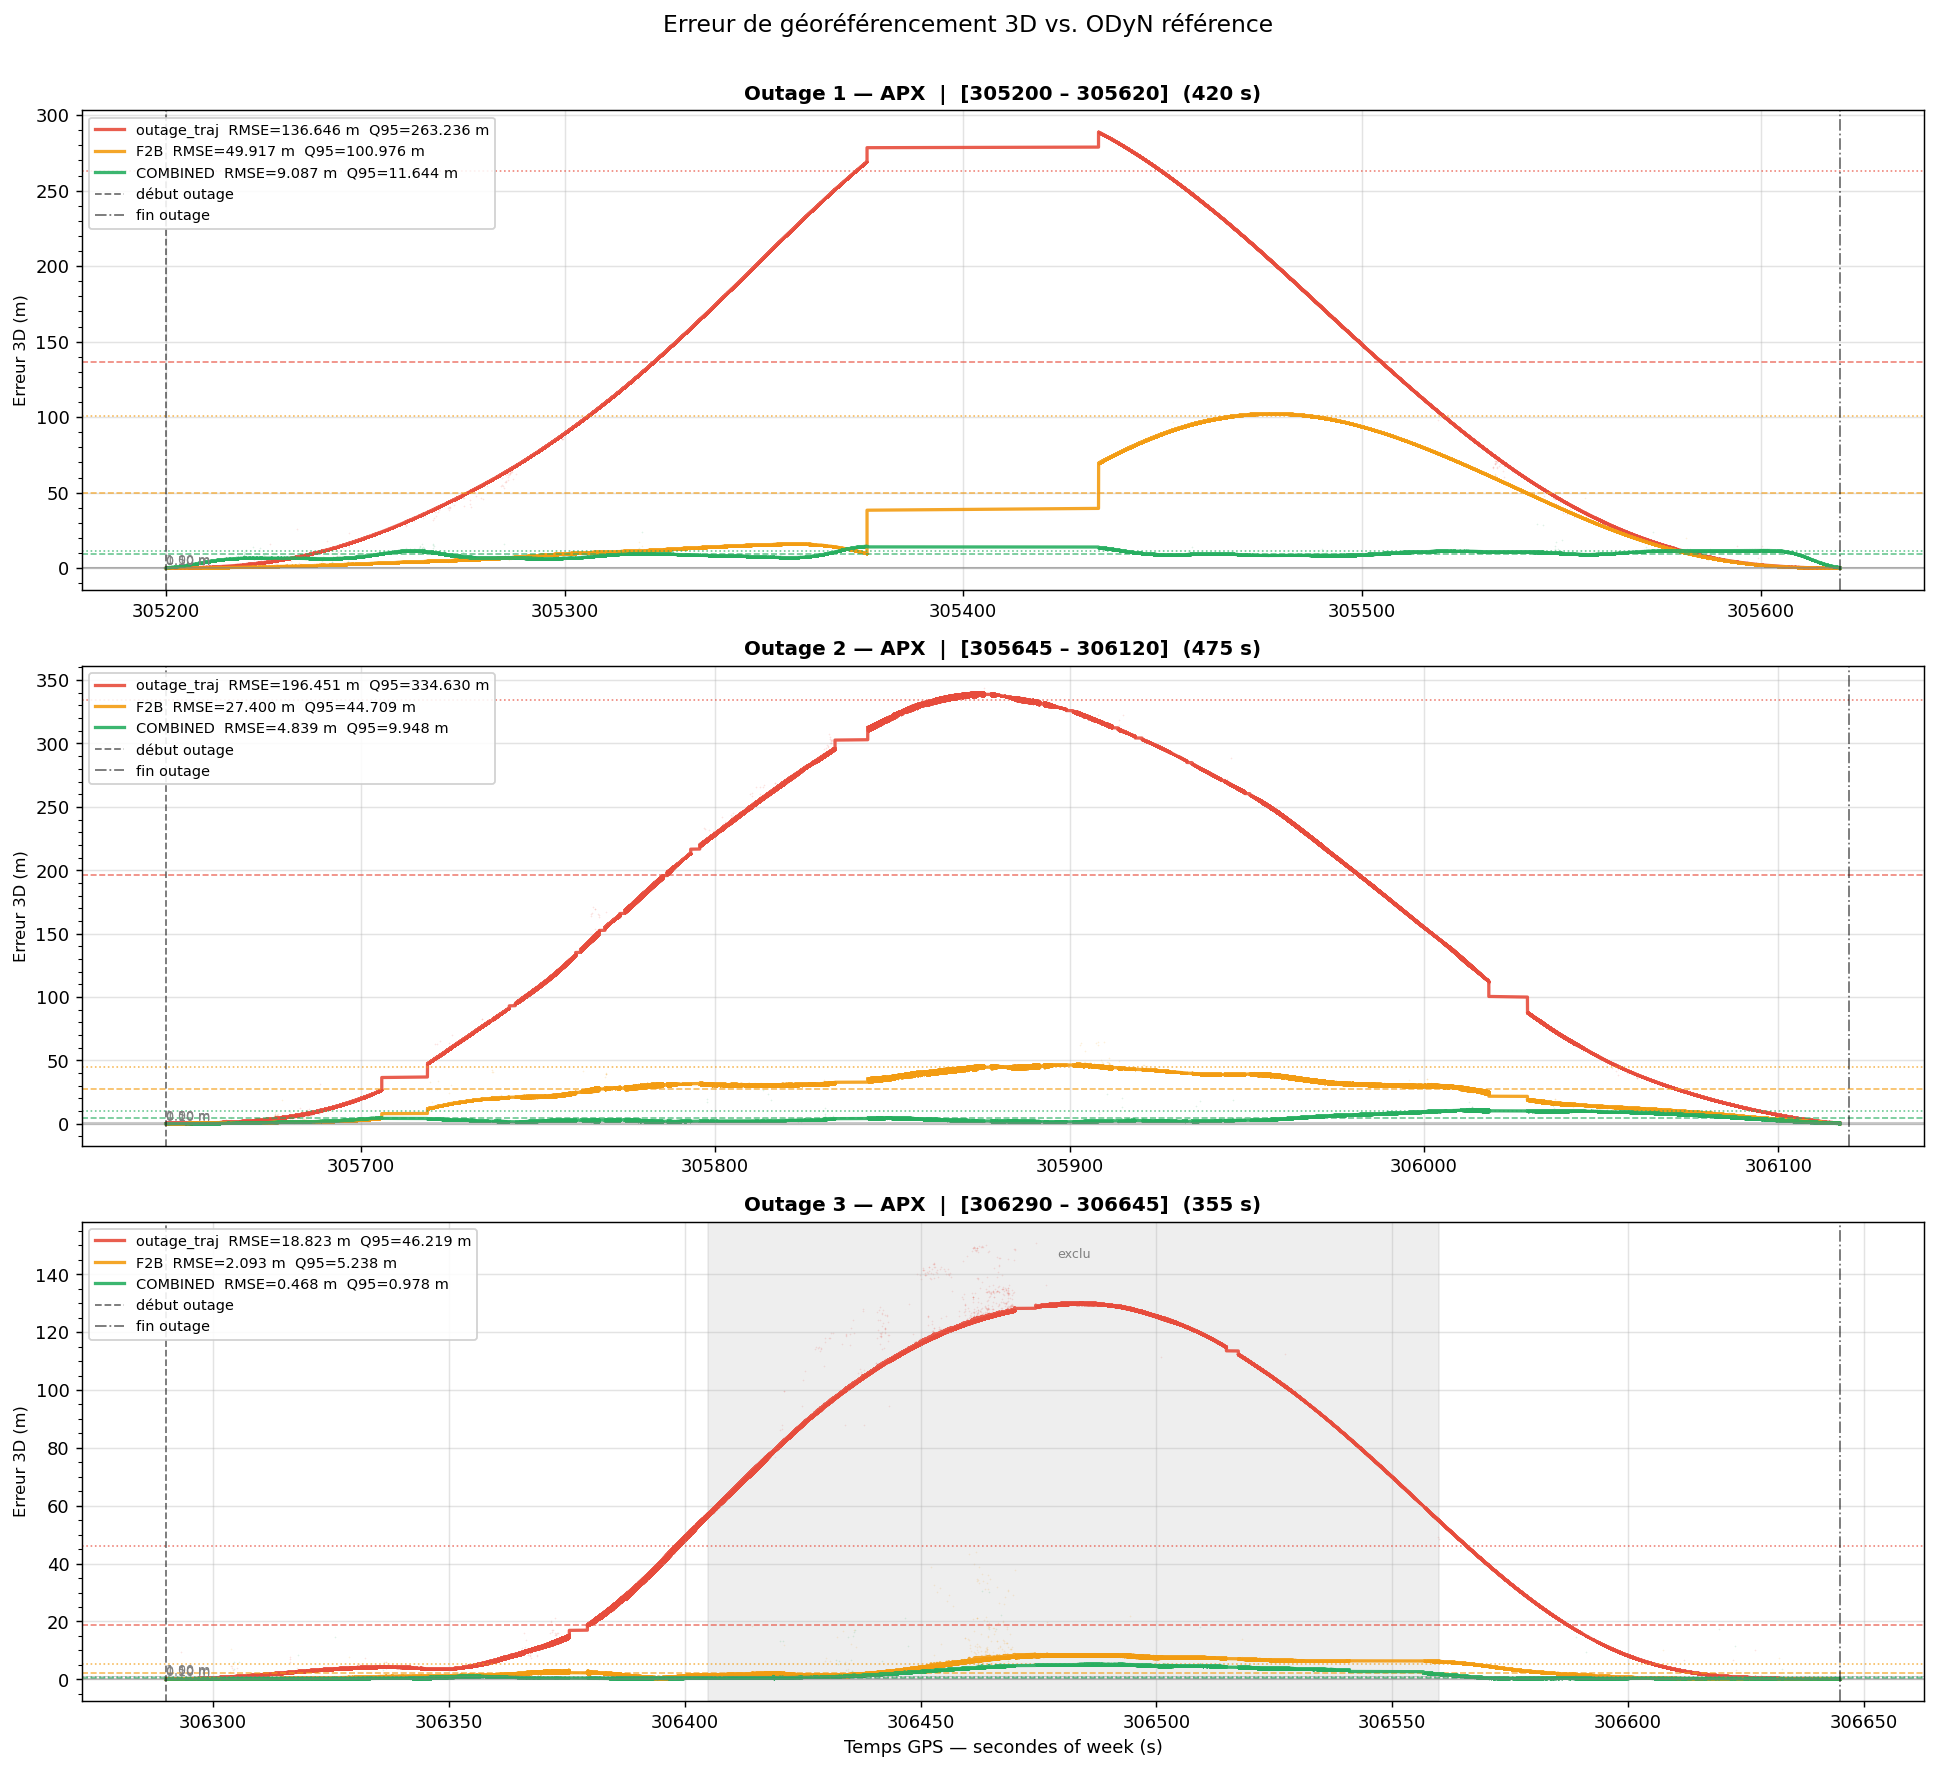

In [ ]:
n_out = len(outages)
fig, axes = plt.subplots(n_out, 1, figsize=(15, 4.5 * n_out), squeeze=False)

for row_i, o in enumerate(outages):
    ax = axes[row_i, 0]
    t_min, t_max = o['t_min'], o['t_max']
    excl = o['exclusion_zones']

    for m_i, (method, (t, e)) in enumerate(o['data'].items()):
        color = method_color(method, m_i)

        mask = np.ones(len(t), dtype=bool)
        if t_min is not None: mask &= (t >= t_min)
        if t_max is not None: mask &= (t <= t_max)
        t_p, e_p = t[mask], e[mask]

        # points bruts (très transparents)
        ax.scatter(t_p, e_p, s=0.8, alpha=0.15, color=color, linewidths=0)

        # courbe lissée
        e_sm = smooth(e_p, SMOOTH_WINDOW)
        mets = compute_metrics(t, e, t_min, t_max, excl)
        label = f"{method}  RMSE={mets['RMSE']:.3f} m  Q95={mets['Q95']:.3f} m"
        ax.plot(t_p, e_sm, color=color, lw=1.8, alpha=0.9, label=label)

        # RMSE et Q95 en tirets
        ax.axhline(mets['RMSE'], color=color, lw=0.9, ls='--', alpha=0.7)
        ax.axhline(mets['Q95'],  color=color, lw=0.9, ls=':',  alpha=0.7)

    # seuils horizontaux
    for thr in THRESHOLD_LINES:
        ax.axhline(thr, color='gray', lw=0.6, alpha=0.4)
        ax.text(t_min or ax.get_xlim()[0], thr + 0.01,
                f'{thr:.2f} m', fontsize=12, color='gray', va='bottom')

    # zones exclues
    for za, zb in excl:
        ax.axvspan(za, zb, color='gray', alpha=0.13, zorder=0)
        ax.text((za+zb)/2, ax.get_ylim()[1]*0.92 if ax.get_ylim()[1]>0 else 1,
                'exclu', ha='center', fontsize=12, color='gray')

    # bornes outage
    ax.axvline(t_min, color='black', lw=1.0, ls='--', alpha=0.55, label='début outage')
    ax.axvline(t_max, color='black', lw=1.0, ls='-.', alpha=0.55, label='fin outage')

    dur = t_max - t_min
    ax.set_title(f"{o['id']} — {o['imu']}  |  [{t_min:.0f} – {t_max:.0f}]  ({dur:.0f} s)",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Erreur 3D (m)', fontsize=12)
    ax.legend(loc='upper left', fontsize=12, framealpha=0.88, markerscale=5)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

axes[-1, 0].set_xlabel('Temps GPS — secondes of week (s)', fontsize=12)
fig.tight_layout()
plt.show()

## ⑥ Plot grille : outage × méthode (un sous-plot par combinaison)

Vue détaillée pour comparer chaque méthode indépendamment à travers les outages.